# Exercise 2: Intel Image Classification with CNN and Transfer Learning

## Author: A.N.R

In [1]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.optim import lr_scheduler
from torch.utils.data import DataLoader
import torchvision
from torchvision import transforms, datasets, models
import numpy as np
import matplotlib.pyplot as plt
import os
from tqdm import tqdm
import time
import copy

torch.manual_seed(42)
np.random.seed(42)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')

Using device: cuda


## Loading and Preprocessing Data

In [2]:
# Dataset paths
data_dir = './Intel Image Classification'
train_dir = os.path.join(data_dir, 'seg_train/seg_train')
test_dir = os.path.join(data_dir, 'seg_test/seg_test')
pred_dir = os.path.join(data_dir, 'seg_pred/seg_pred')

# Check dataset existence
if os.path.exists(train_dir):
    print(f'Train directory found: {train_dir}')
    print(f'Classes: {os.listdir(train_dir)}')
else:
    print('Dataset not found!')

Train directory found: ./Intel Image Classification/seg_train/seg_train
Classes: ['street', 'buildings', 'mountain', 'forest', 'glacier', 'sea']


In [3]:
# Define transforms
data_transforms = {
    'train': transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.RandomHorizontalFlip(),
        transforms.RandomRotation(10),
        transforms.ColorJitter(brightness=0.2, contrast=0.2, saturation=0.2),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
    'val': transforms.Compose([
        transforms.Resize((150, 150)),
        transforms.ToTensor(),
        transforms.Normalize([0.485, 0.456, 0.406], [0.229, 0.224, 0.225])
    ]),
}

# Load dataset
full_train_dataset = datasets.ImageFolder(train_dir, transform=data_transforms['train'])
test_dataset = datasets.ImageFolder(test_dir, transform=data_transforms['val'])

# Split train into train and validation (90-10)
train_size = int(0.9 * len(full_train_dataset))
val_size = len(full_train_dataset) - train_size
train_dataset, val_dataset = torch.utils.data.random_split(full_train_dataset, [train_size, val_size])

# Create dataloaders
batch_size = 32
train_loader = DataLoader(train_dataset, batch_size=batch_size, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, batch_size=batch_size, shuffle=False, num_workers=2)
test_loader = DataLoader(test_dataset, batch_size=batch_size, shuffle=False, num_workers=2)

dataset_sizes = {'train': len(train_dataset), 'val': len(val_dataset), 'test': len(test_dataset)}
class_names = full_train_dataset.classes

print(f'Training samples: {dataset_sizes["train"]}')
print(f'Validation samples: {dataset_sizes["val"]}')
print(f'Test samples: {dataset_sizes["test"]}')
print(f'Number of classes: {len(class_names)}')
print(f'Classes: {class_names}')

Training samples: 12630
Validation samples: 1404
Test samples: 3000
Number of classes: 6
Classes: ['buildings', 'forest', 'glacier', 'mountain', 'sea', 'street']


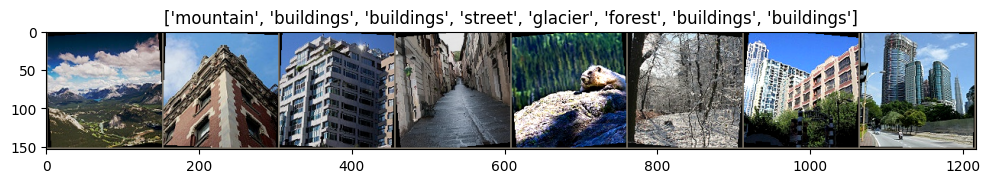

<Figure size 640x480 with 0 Axes>

In [4]:
# Display some dataset samples
def imshow(inp, title=None):
    inp = inp.numpy().transpose((1, 2, 0))
    mean = np.array([0.485, 0.456, 0.406])
    std = np.array([0.229, 0.224, 0.225])
    inp = std * inp + mean
    inp = np.clip(inp, 0, 1)
    plt.imshow(inp)
    if title is not None:
        plt.title(title)
    plt.pause(0.001)

# Display a batch of images
inputs, classes = next(iter(train_loader))
out = torchvision.utils.make_grid(inputs[:8])
plt.figure(figsize=(12, 6))
imshow(out, title=[class_names[x] for x in classes[:8]])
plt.savefig('sample_images.png', dpi=100, bbox_inches='tight')
plt.show()

## Part (a): Design and Train CNN from Scratch

In [5]:
class IntelCNN(nn.Module):
    def __init__(self, num_classes=6):
        super(IntelCNN, self).__init__()
        
        # Block 1
        self.conv1 = nn.Conv2d(3, 64, kernel_size=3, padding=1)
        self.bn1 = nn.BatchNorm2d(64)
        self.relu1 = nn.ReLU(inplace=True)
        self.conv2 = nn.Conv2d(64, 64, kernel_size=3, padding=1)
        self.bn2 = nn.BatchNorm2d(64)
        self.relu2 = nn.ReLU(inplace=True)
        self.pool1 = nn.MaxPool2d(2, 2)
        self.dropout1 = nn.Dropout(0.25)
        
        # Block 2
        self.conv3 = nn.Conv2d(64, 128, kernel_size=3, padding=1)
        self.bn3 = nn.BatchNorm2d(128)
        self.relu3 = nn.ReLU(inplace=True)
        self.conv4 = nn.Conv2d(128, 128, kernel_size=3, padding=1)
        self.bn4 = nn.BatchNorm2d(128)
        self.relu4 = nn.ReLU(inplace=True)
        self.pool2 = nn.MaxPool2d(2, 2)
        self.dropout2 = nn.Dropout(0.25)
        
        # Block 3
        self.conv5 = nn.Conv2d(128, 256, kernel_size=3, padding=1)
        self.bn5 = nn.BatchNorm2d(256)
        self.relu5 = nn.ReLU(inplace=True)
        self.conv6 = nn.Conv2d(256, 256, kernel_size=3, padding=1)
        self.bn6 = nn.BatchNorm2d(256)
        self.relu6 = nn.ReLU(inplace=True)
        self.pool3 = nn.MaxPool2d(2, 2)
        self.dropout3 = nn.Dropout(0.25)
        
        # Block 4
        self.conv7 = nn.Conv2d(256, 512, kernel_size=3, padding=1)
        self.bn7 = nn.BatchNorm2d(512)
        self.relu7 = nn.ReLU(inplace=True)
        self.conv8 = nn.Conv2d(512, 512, kernel_size=3, padding=1)
        self.bn8 = nn.BatchNorm2d(512)
        self.relu8 = nn.ReLU(inplace=True)
        self.pool4 = nn.MaxPool2d(2, 2)
        self.dropout4 = nn.Dropout(0.25)
        
        # Fully Connected
        self.flatten = nn.Flatten()
        self.fc1 = nn.Linear(512 * 9 * 9, 1024)
        self.relu9 = nn.ReLU(inplace=True)
        self.dropout5 = nn.Dropout(0.5)
        self.fc2 = nn.Linear(1024, 512)
        self.relu10 = nn.ReLU(inplace=True)
        self.dropout6 = nn.Dropout(0.5)
        self.fc3 = nn.Linear(512, num_classes)
        
    def forward(self, x):
        x = self.conv1(x)
        x = self.bn1(x)
        x = self.relu1(x)
        x = self.conv2(x)
        x = self.bn2(x)
        x = self.relu2(x)
        x = self.pool1(x)
        x = self.dropout1(x)
        
        x = self.conv3(x)
        x = self.bn3(x)
        x = self.relu3(x)
        x = self.conv4(x)
        x = self.bn4(x)
        x = self.relu4(x)
        x = self.pool2(x)
        x = self.dropout2(x)
        
        x = self.conv5(x)
        x = self.bn5(x)
        x = self.relu5(x)
        x = self.conv6(x)
        x = self.bn6(x)
        x = self.relu6(x)
        x = self.pool3(x)
        x = self.dropout3(x)
        
        x = self.conv7(x)
        x = self.bn7(x)
        x = self.relu7(x)
        x = self.conv8(x)
        x = self.bn8(x)
        x = self.relu8(x)
        x = self.pool4(x)
        x = self.dropout4(x)
        
        x = self.flatten(x)
        x = self.fc1(x)
        x = self.relu9(x)
        x = self.dropout5(x)
        x = self.fc2(x)
        x = self.relu10(x)
        x = self.dropout6(x)
        x = self.fc3(x)
        
        return x

# Create model
scratch_model = IntelCNN(num_classes=len(class_names)).to(device)
print(scratch_model)

total_params = sum(p.numel() for p in scratch_model.parameters())
trainable_params = sum(p.numel() for p in scratch_model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

IntelCNN(
  (conv1): Conv2d(3, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu1): ReLU(inplace=True)
  (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu2): ReLU(inplace=True)
  (pool1): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
  (dropout1): Dropout(p=0.25, inplace=False)
  (conv3): Conv2d(64, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn3): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu3): ReLU(inplace=True)
  (conv4): Conv2d(128, 128, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
  (bn4): BatchNorm2d(128, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu4): ReLU(inplace=True)
  (pool2): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ce

In [6]:
def train_model(model, dataloaders, criterion, optimizer, scheduler, num_epochs=25):
    since = time.time()
    
    best_model_wts = copy.deepcopy(model.state_dict())
    best_acc = 0.0
    
    history = {
        'train_loss': [],
        'train_acc': [],
        'val_loss': [],
        'val_acc': []
    }
    
    for epoch in range(num_epochs):
        print(f'Epoch {epoch+1}/{num_epochs}')
        print('-' * 60)
        
        for phase in ['train', 'val']:
            if phase == 'train':
                model.train()
            else:
                model.eval()
            
            running_loss = 0.0
            running_corrects = 0
            
            dataloader = dataloaders[phase]
            for inputs, labels in tqdm(dataloader, desc=f'{phase}'):
                inputs = inputs.to(device)
                labels = labels.to(device)
                
                optimizer.zero_grad()
                
                with torch.set_grad_enabled(phase == 'train'):
                    outputs = model(inputs)
                    _, preds = torch.max(outputs, 1)
                    loss = criterion(outputs, labels)
                    
                    if phase == 'train':
                        loss.backward()
                        optimizer.step()
                
                running_loss += loss.item() * inputs.size(0)
                running_corrects += torch.sum(preds == labels.data)
            
            if phase == 'train' and scheduler is not None:
                scheduler.step()
            
            epoch_loss = running_loss / dataset_sizes[phase]
            epoch_acc = running_corrects.double() / dataset_sizes[phase]
            
            history[f'{phase}_loss'].append(epoch_loss)
            history[f'{phase}_acc'].append(epoch_acc.item())
            
            print(f'{phase} Loss: {epoch_loss:.4f} Acc: {epoch_acc:.4f}')
            
            if phase == 'val' and epoch_acc > best_acc:
                best_acc = epoch_acc
                best_model_wts = copy.deepcopy(model.state_dict())
                print(f'*** New best model saved with val acc: {best_acc:.4f} ***')
        
        print()
    
    time_elapsed = time.time() - since
    print(f'Training complete in {time_elapsed // 60:.0f}m {time_elapsed % 60:.0f}s')
    print(f'Best val Acc: {best_acc:.4f}')
    
    model.load_state_dict(best_model_wts)
    return model, history, best_acc

In [7]:
# Training settings
criterion = nn.CrossEntropyLoss()
optimizer_scratch = optim.Adam(scratch_model.parameters(), lr=0.001)
scheduler_scratch = lr_scheduler.StepLR(optimizer_scratch, step_size=7, gamma=0.1)

dataloaders = {'train': train_loader, 'val': val_loader}

# Train model
print('Starting to train CNN model from scratch...')
print('='*60)
scratch_model, scratch_history, scratch_best_acc = train_model(
    scratch_model, dataloaders, criterion, optimizer_scratch, 
    scheduler_scratch, num_epochs=25
)

Starting to train CNN model from scratch...
Epoch 1/25
------------------------------------------------------------


train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 395/395 [00:16<00:00, 24.49it/s]


train Loss: 1.8568 Acc: 0.4014


val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 54.31it/s]


val Loss: 1.0858 Acc: 0.5570
*** New best model saved with val acc: 0.5570 ***

Epoch 2/25
------------------------------------------------------------


...

val Loss: 0.4516 Acc: 0.8412

Epoch 25/25
------------------------------------------------------------


train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 395/395 [00:15<00:00, 24.89it/s]


train Loss: 0.4590 Acc: 0.8390


val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 60.81it/s]

val Loss: 0.4472 Acc: 0.8412

Training complete in 6m 56s
Best val Acc: 0.8490


## Part (b): Model Evaluation on Test Data

In [8]:
def evaluate_model(model, test_loader, device):
    model.eval()
    running_corrects = 0
    all_preds = []
    all_labels = []
    
    with torch.no_grad():
        for inputs, labels in tqdm(test_loader, desc='Testing'):
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            running_corrects += torch.sum(preds == labels.data)
            all_preds.extend(preds.cpu().numpy())
            all_labels.extend(labels.cpu().numpy())
    
    test_acc = running_corrects.double() / len(test_loader.dataset)
    return test_acc, all_preds, all_labels

scratch_test_acc, scratch_preds, scratch_labels = evaluate_model(scratch_model, test_loader, device)
print(f'\nTest Accuracy (Scratch Model): {scratch_test_acc:.4f}')

Testing: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:01<00:00, 72.42it/s]


Test Accuracy (Scratch Model): 0.8517


## Visualizing Initial Model Results

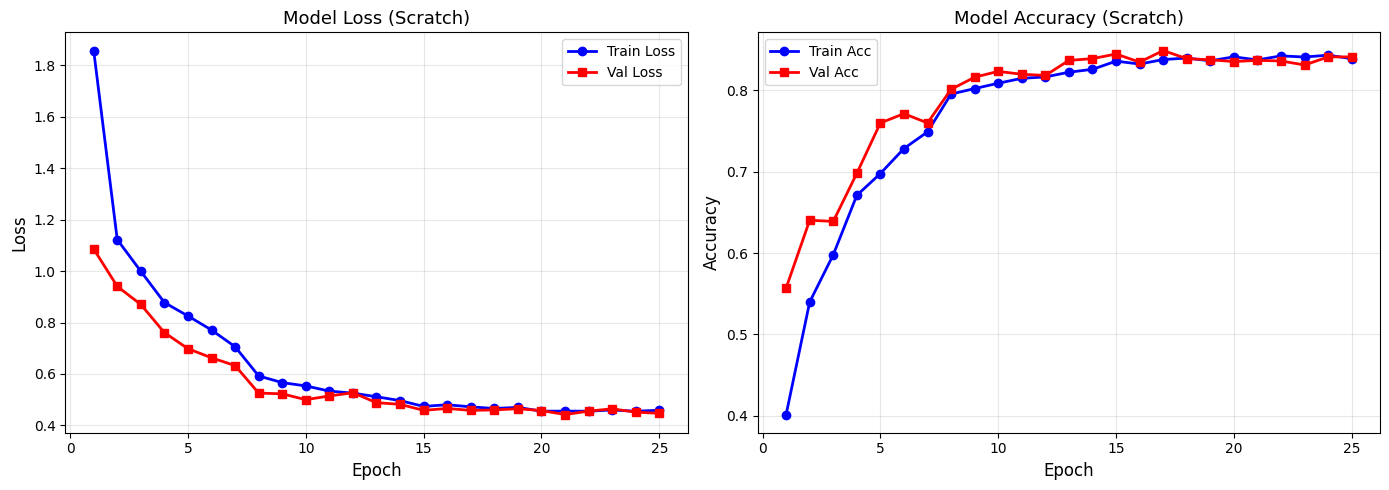

In [9]:
# Plot training history
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

epochs_range = range(1, len(scratch_history['train_loss']) + 1)

ax1.plot(epochs_range, scratch_history['train_loss'], 'b-o', label='Train Loss', linewidth=2)
ax1.plot(epochs_range, scratch_history['val_loss'], 'r-s', label='Val Loss', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Model Loss (Scratch)', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

ax2.plot(epochs_range, scratch_history['train_acc'], 'b-o', label='Train Acc', linewidth=2)
ax2.plot(epochs_range, scratch_history['val_acc'], 'r-s', label='Val Acc', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('Accuracy', fontsize=12)
ax2.set_title('Model Accuracy (Scratch)', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('scratch_model_history.png', dpi=150, bbox_inches='tight')
plt.show()

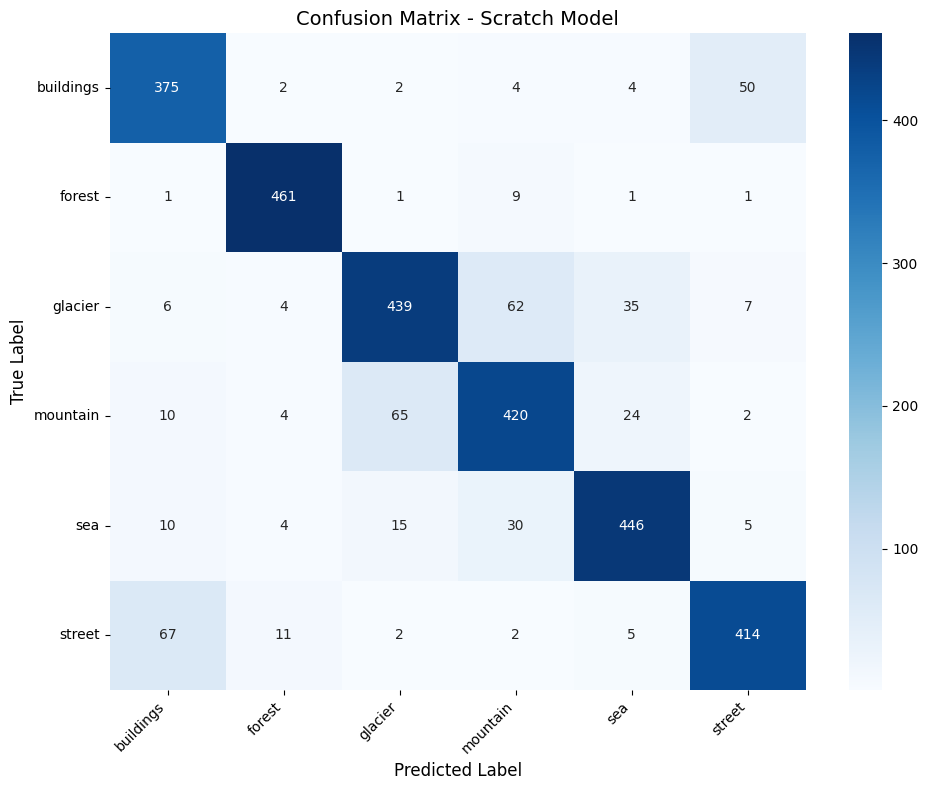

Classification Report (Scratch Model):
              precision    recall  f1-score   support

   buildings       0.80      0.86      0.83       437
      forest       0.95      0.97      0.96       474
     glacier       0.84      0.79      0.82       553
    mountain       0.80      0.80      0.80       525
         sea       0.87      0.87      0.87       510
      street       0.86      0.83      0.84       501

    accuracy                           0.85      3000
   macro avg       0.85      0.85      0.85      3000
weighted avg       0.85      0.85      0.85      3000



In [10]:
# Confusion Matrix
from sklearn.metrics import confusion_matrix, classification_report
import seaborn as sns

cm_scratch = confusion_matrix(scratch_labels, scratch_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_scratch, annot=True, fmt='d', cmap='Blues', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Scratch Model', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('scratch_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('Classification Report (Scratch Model):')
print(classification_report(scratch_labels, scratch_preds, target_names=class_names))

## Part (c): Transfer Learning with ResNet50

In [11]:
# Load pre-trained ResNet50 model
print('Loading ResNet50 with ImageNet weights...')
resnet_model = models.resnet50(pretrained=True)

# Freeze all layers
for param in resnet_model.parameters():
    param.requires_grad = False

# Change last layer
num_ftrs = resnet_model.fc.in_features
resnet_model.fc = nn.Linear(num_ftrs, len(class_names))
resnet_model = resnet_model.to(device)

print(f'\nResNet50 architecture:')
print(resnet_model)

total_params = sum(p.numel() for p in resnet_model.parameters())
trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f'\nTotal parameters: {total_params:,}')
print(f'Trainable parameters: {trainable_params:,}')

Loading ResNet50 with ImageNet weights...
Downloading: "https://download.pytorch.org/models/resnet50-0676ba61.pth" to /home/ahmad/.cache/torch/hub/checkpoints/resnet50-0676ba61.pth


/home/ahmad/Documents/phd-courses/deep-network/HomeWorks/4/myenv/lib/python3.11/site-packages/torchvision/models/_utils.py:208: UserWarning: The parameter 'pretrained' is deprecated since 0.13 and may be removed in the future, please use 'weights' instead.
  warnings.warn(
/home/ahmad/Documents/phd-courses/deep-network/HomeWorks/4/myenv/lib/python3.11/site-packages/torchvision/models/_utils.py:223: UserWarning: Arguments other than a weight enum or `None` for 'weights' are deprecated since 0.13 and may be removed in the future. The current behavior is equivalent to passing `weights=ResNet50_Weights.IMAGENET1K_V1`. You can also use `weights=ResNet50_Weights.DEFAULT` to get the most up-to-date weights.
  warnings.warn(msg)
100%|██████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 97.8M/97.8M [01:45<00:00, 971kB/s]


ResNet50 architecture:
ResNet(
  (conv1): Conv2d(3, 64, kernel_size=(7, 7), stride=(2, 2), padding=(3, 3), bias=False)
  (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
  (relu): ReLU(inplace=True)
  (maxpool): MaxPool2d(kernel_size=3, stride=2, padding=1, dilation=1, ceil_mode=False)
  (layer1): Sequential(
    (0): Bottleneck(
      (conv1): Conv2d(64, 64, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv2): Conv2d(64, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1), bias=False)
      (bn2): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (conv3): Conv2d(64, 256, kernel_size=(1, 1), stride=(1, 1), bias=False)
      (bn3): BatchNorm2d(256, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
      (relu): ReLU(inplace=True)
      (downsample): Sequential(
        (0): Conv2d(64, 256, kernel_

In [12]:
# Training settings for transfer learning
criterion = nn.CrossEntropyLoss()
optimizer_resnet = optim.Adam(resnet_model.fc.parameters(), lr=0.001)
scheduler_resnet = lr_scheduler.StepLR(optimizer_resnet, step_size=5, gamma=0.1)

# Train model transfer learning
print('\nStarting training with Transfer Learning (ResNet50)...')
print('='*60)
resnet_model, resnet_history, resnet_best_acc = train_model(
    resnet_model, dataloaders, criterion, optimizer_resnet, 
    scheduler_resnet, num_epochs=15
)


Starting training with Transfer Learning (ResNet50)...
Epoch 1/15
------------------------------------------------------------


train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 395/395 [00:05<00:00, 66.89it/s]


train Loss: 0.5266 Acc: 0.8224


val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 60.61it/s]


val Loss: 0.3706 Acc: 0.8590
*** New best model saved with val acc: 0.8590 ***

Epoch 2/15
------------------------------------------------------------


...

val Loss: 0.3005 Acc: 0.8967
*** New best model saved with val acc: 0.8967 ***

Epoch 15/15
------------------------------------------------------------


train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 395/395 [00:05<00:00, 69.03it/s]


train Loss: 0.2896 Acc: 0.8958


val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 61.01it/s]

val Loss: 0.2861 Acc: 0.8910

Training complete in 1m 38s
Best val Acc: 0.8967


In [13]:
# Evaluate ResNet model on test
resnet_test_acc, resnet_preds, resnet_labels = evaluate_model(resnet_model, test_loader, device)
print(f'\nTest Accuracy (ResNet50 Transfer Learning): {resnet_test_acc:.4f}')

Testing: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:00<00:00, 113.14it/s]


Test Accuracy (ResNet50 Transfer Learning): 0.8960


## Fine-tuning: Unfreezing Last Layers

In [14]:
# Fine-tuning: Unfreezing layers layer4
print('Fine-tuning: Unfreezing last layers...')
for param in resnet_model.layer4.parameters():
    param.requires_grad = True
for param in resnet_model.fc.parameters():
    param.requires_grad = True

trainable_params = sum(p.numel() for p in resnet_model.parameters() if p.requires_grad)
print(f'Trainable parameters after unfreezing: {trainable_params:,}')

# Training settings with lower learning rate
optimizer_finetune = optim.Adam(filter(lambda p: p.requires_grad, resnet_model.parameters()), lr=0.0001)
scheduler_finetune = lr_scheduler.StepLR(optimizer_finetune, step_size=5, gamma=0.1)

# Fine-tuning
print('\nStarting Fine-tuning...')
print('='*60)
resnet_finetuned, finetune_history, finetune_best_acc = train_model(
    resnet_model, dataloaders, criterion, optimizer_finetune, 
    scheduler_finetune, num_epochs=10
)

Fine-tuning: Unfreezing last layers...
Trainable parameters after unfreezing: 14,977,030

Starting Fine-tuning...
Epoch 1/10
------------------------------------------------------------


train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 395/395 [00:05<00:00, 67.13it/s]


train Loss: 0.3095 Acc: 0.8923


val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 61.79it/s]


val Loss: 0.2348 Acc: 0.9209
*** New best model saved with val acc: 0.9209 ***

Epoch 2/10
------------------------------------------------------------


...

val Loss: 0.2472 Acc: 0.9302
*** New best model saved with val acc: 0.9302 ***

Epoch 10/10
------------------------------------------------------------


train: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 395/395 [00:05<00:00, 67.89it/s]


train Loss: 0.0365 Acc: 0.9866


val: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 59.45it/s]

val Loss: 0.2822 Acc: 0.9259

Training complete in 1m 6s
Best val Acc: 0.9302


In [15]:
# Evaluate fine-tuned model
finetune_test_acc, finetune_preds, finetune_labels = evaluate_model(resnet_finetuned, test_loader, device)
print(f'\nTest Accuracy (Fine-tuned ResNet50): {finetune_test_acc:.4f}')

Testing: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:00<00:00, 115.03it/s]


Test Accuracy (Fine-tuned ResNet50): 0.9313


## Part (d): Analysis and Results Report

In [16]:
# Compare results
results_comparison = {
    'Model': ['Scratch CNN', 'ResNet50 (Transfer)', 'ResNet50 (Fine-tuned)'],
    'Best Val Acc': [scratch_best_acc.item(), resnet_best_acc.item(), finetune_best_acc.item()],
    'Test Acc': [scratch_test_acc.item(), resnet_test_acc.item(), finetune_test_acc.item()],
    'Trainable Params': [
        sum(p.numel() for p in scratch_model.parameters()),
        len(class_names) * 2048 + len(class_names),  # فقط fc layer
        trainable_params
    ]
}

import pandas as pd
df_results = pd.DataFrame(results_comparison)
print('\n' + '='*80)
print('Final Results Comparison')
print('='*80)
print(df_results.to_string(index=False))
print('='*80)


Final Results Comparison
                Model  Best Val Acc  Test Acc  Trainable Params
          Scratch CNN      0.849003  0.851667          47685446
  ResNet50 (Transfer)      0.896724  0.896000             12294
ResNet50 (Fine-tuned)      0.930199  0.931333          14977030


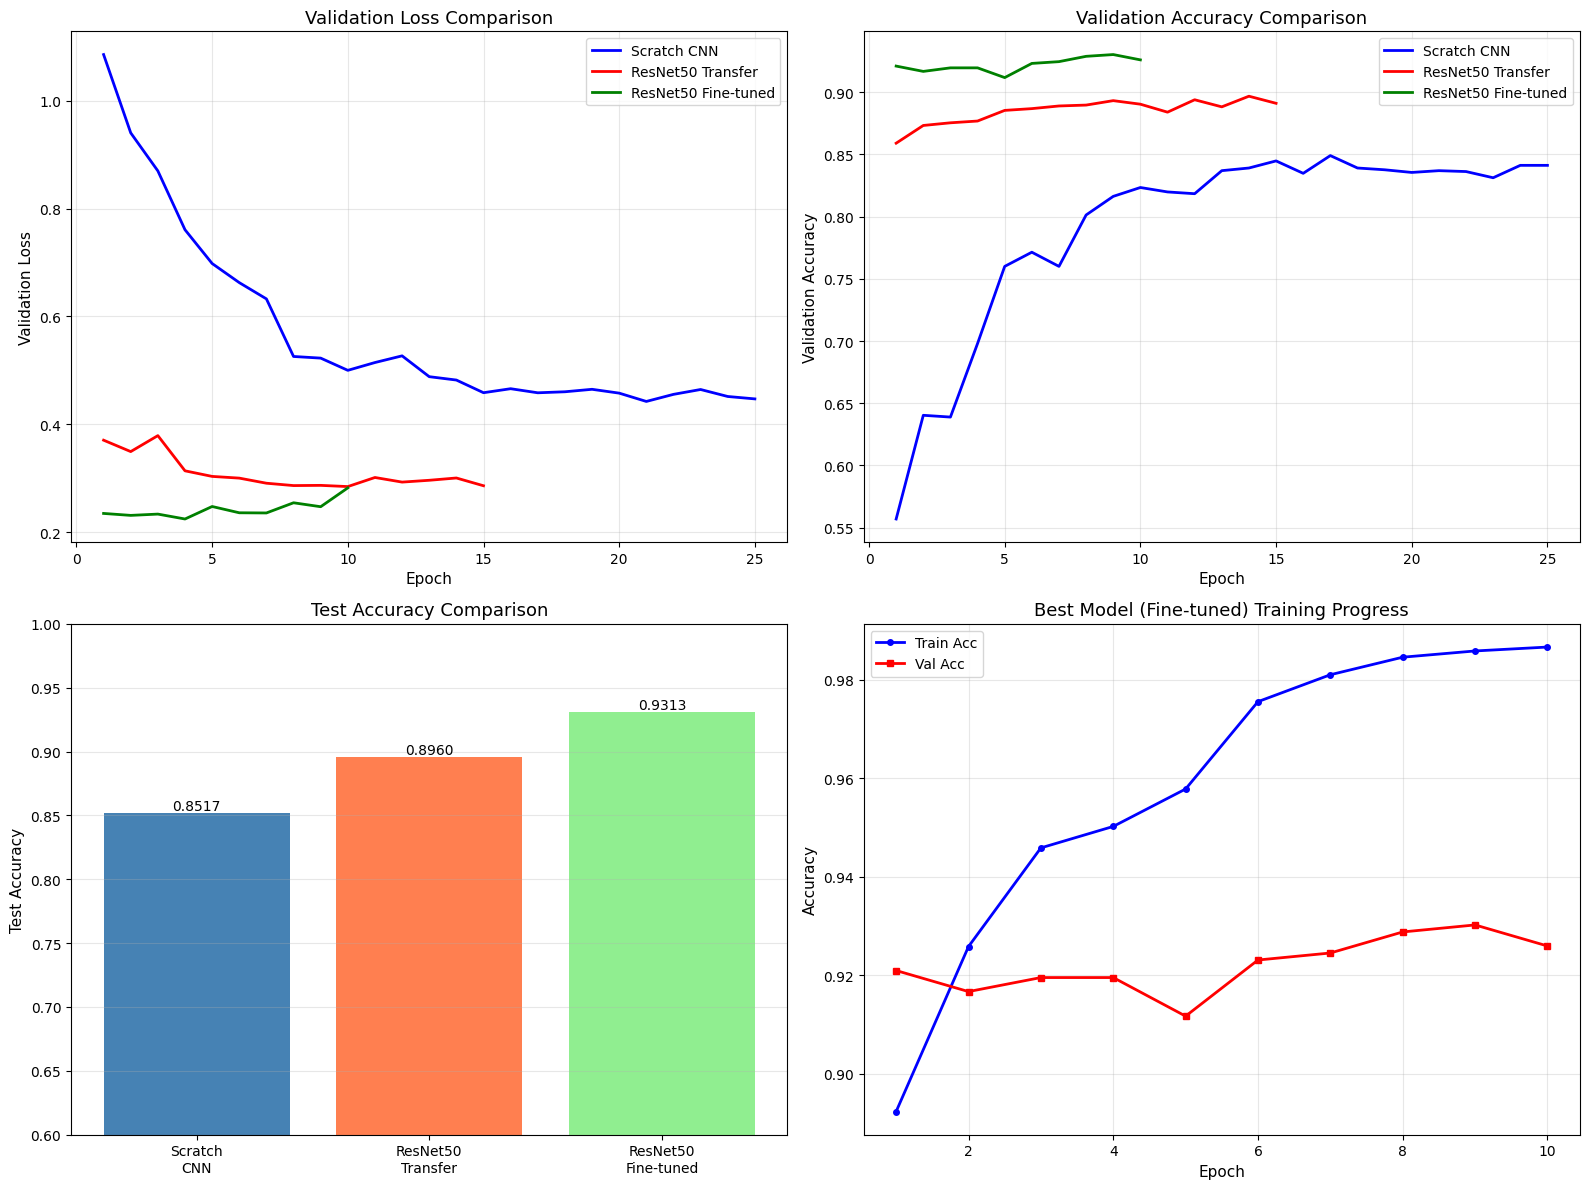

In [17]:
# Comparison charts
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

# Loss comparison
ax1 = axes[0, 0]
epochs_scratch = range(1, len(scratch_history['val_loss']) + 1)
epochs_resnet = range(1, len(resnet_history['val_loss']) + 1)
epochs_finetune = range(1, len(finetune_history['val_loss']) + 1)

ax1.plot(epochs_scratch, scratch_history['val_loss'], 'b-', label='Scratch CNN', linewidth=2)
ax1.plot(epochs_resnet, resnet_history['val_loss'], 'r-', label='ResNet50 Transfer', linewidth=2)
ax1.plot(epochs_finetune, finetune_history['val_loss'], 'g-', label='ResNet50 Fine-tuned', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=11)
ax1.set_ylabel('Validation Loss', fontsize=11)
ax1.set_title('Validation Loss Comparison', fontsize=13)
ax1.legend()
ax1.grid(True, alpha=0.3)

# Accuracy comparison
ax2 = axes[0, 1]
ax2.plot(epochs_scratch, scratch_history['val_acc'], 'b-', label='Scratch CNN', linewidth=2)
ax2.plot(epochs_resnet, resnet_history['val_acc'], 'r-', label='ResNet50 Transfer', linewidth=2)
ax2.plot(epochs_finetune, finetune_history['val_acc'], 'g-', label='ResNet50 Fine-tuned', linewidth=2)
ax2.set_xlabel('Epoch', fontsize=11)
ax2.set_ylabel('Validation Accuracy', fontsize=11)
ax2.set_title('Validation Accuracy Comparison', fontsize=13)
ax2.legend()
ax2.grid(True, alpha=0.3)

# Test accuracy bar chart
ax3 = axes[1, 0]
models = ['Scratch\nCNN', 'ResNet50\nTransfer', 'ResNet50\nFine-tuned']
test_accs = [scratch_test_acc.item(), resnet_test_acc.item(), finetune_test_acc.item()]
colors = ['steelblue', 'coral', 'lightgreen']
bars = ax3.bar(models, test_accs, color=colors)
ax3.set_ylabel('Test Accuracy', fontsize=11)
ax3.set_title('Test Accuracy Comparison', fontsize=13)
ax3.set_ylim([0.6, 1.0])
ax3.grid(True, alpha=0.3, axis='y')
for bar in bars:
    height = bar.get_height()
    ax3.text(bar.get_x() + bar.get_width()/2., height,
            f'{height:.4f}', ha='center', va='bottom', fontsize=10)

# Training vs validation for best model
ax4 = axes[1, 1]
ax4.plot(epochs_finetune, finetune_history['train_acc'], 'b-o', label='Train Acc', linewidth=2, markersize=4)
ax4.plot(epochs_finetune, finetune_history['val_acc'], 'r-s', label='Val Acc', linewidth=2, markersize=4)
ax4.set_xlabel('Epoch', fontsize=11)
ax4.set_ylabel('Accuracy', fontsize=11)
ax4.set_title('Best Model (Fine-tuned) Training Progress', fontsize=13)
ax4.legend()
ax4.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('all_models_comparison.png', dpi=150, bbox_inches='tight')
plt.show()

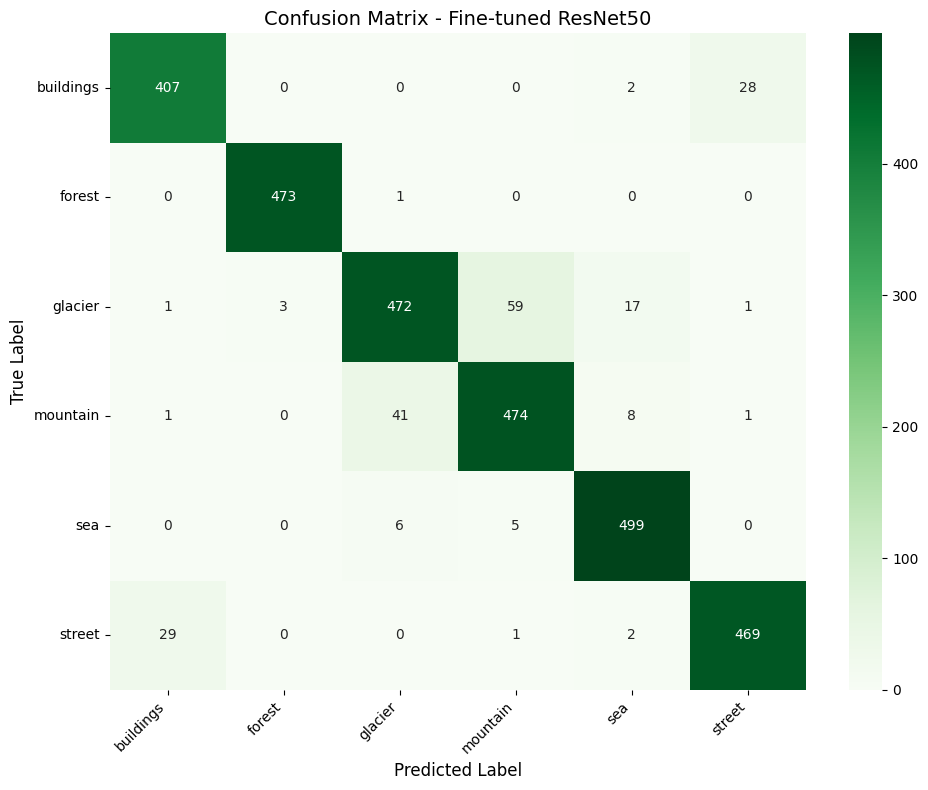


Classification Report (Fine-tuned ResNet50):
              precision    recall  f1-score   support

   buildings       0.93      0.93      0.93       437
      forest       0.99      1.00      1.00       474
     glacier       0.91      0.85      0.88       553
    mountain       0.88      0.90      0.89       525
         sea       0.95      0.98      0.96       510
      street       0.94      0.94      0.94       501

    accuracy                           0.93      3000
   macro avg       0.93      0.93      0.93      3000
weighted avg       0.93      0.93      0.93      3000



In [18]:
# Confusion matrix for best model
cm_finetune = confusion_matrix(finetune_labels, finetune_preds)

plt.figure(figsize=(10, 8))
sns.heatmap(cm_finetune, annot=True, fmt='d', cmap='Greens', 
            xticklabels=class_names, yticklabels=class_names)
plt.title('Confusion Matrix - Fine-tuned ResNet50', fontsize=14)
plt.ylabel('True Label', fontsize=12)
plt.xlabel('Predicted Label', fontsize=12)
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.savefig('finetune_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()

print('\nClassification Report (Fine-tuned ResNet50):')
print(classification_report(finetune_labels, finetune_preds, target_names=class_names))

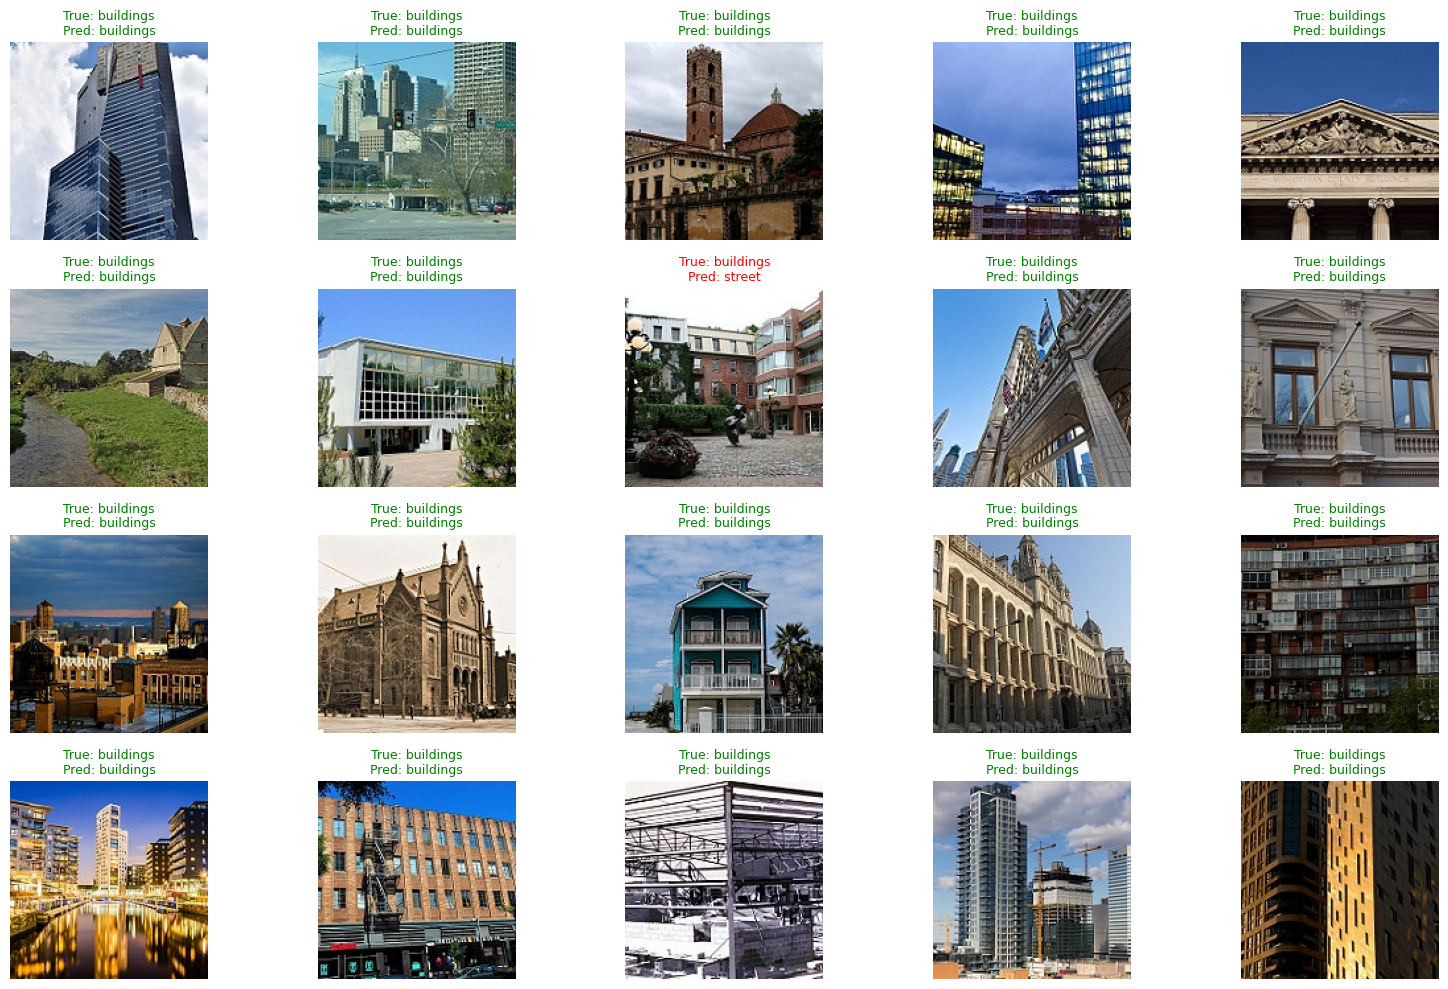

In [19]:
# Display samples from predictions
def visualize_predictions(model, test_loader, class_names, num_images=20):
    model.eval()
    images_so_far = 0
    fig = plt.figure(figsize=(16, 10))
    
    with torch.no_grad():
        for inputs, labels in test_loader:
            inputs = inputs.to(device)
            labels = labels.to(device)
            
            outputs = model(inputs)
            _, preds = torch.max(outputs, 1)
            
            for j in range(inputs.size()[0]):
                images_so_far += 1
                ax = plt.subplot(4, 5, images_so_far)
                ax.axis('off')
                
                img = inputs.cpu().data[j]
                img = img.numpy().transpose((1, 2, 0))
                mean = np.array([0.485, 0.456, 0.406])
                std = np.array([0.229, 0.224, 0.225])
                img = std * img + mean
                img = np.clip(img, 0, 1)
                
                ax.imshow(img)
                color = 'green' if preds[j] == labels[j] else 'red'
                ax.set_title(f'True: {class_names[labels[j]]}\nPred: {class_names[preds[j]]}',
                           fontsize=9, color=color)
                
                if images_so_far == num_images:
                    return

visualize_predictions(resnet_finetuned, test_loader, class_names)
plt.tight_layout()
plt.savefig('sample_predictions.png', dpi=150, bbox_inches='tight')
plt.show()

## Part (e): Feature Extraction from Second-to-Last Layer

In [20]:
# Extract features using best model
class FeatureExtractor(nn.Module):
    def __init__(self, model):
        super(FeatureExtractor, self).__init__()
        # Remove last layer (fc)
        self.features = nn.Sequential(*list(model.children())[:-1])
        
    def forward(self, x):
        x = self.features(x)
        x = torch.flatten(x, 1)
        return x

feature_extractor = FeatureExtractor(resnet_finetuned).to(device)
feature_extractor.eval()

print('Feature extractor created successfully!')
print(f'Feature vector size: {num_ftrs}')

Feature extractor created successfully!
Feature vector size: 2048


In [21]:
def extract_features(model, dataloader, device):
    model.eval()
    features_list = []
    labels_list = []
    paths_list = []
    
    with torch.no_grad():
        for i, (inputs, labels) in enumerate(tqdm(dataloader, desc='Extracting features')):
            inputs = inputs.to(device)
            features = model(inputs)
            
            features_list.append(features.cpu().numpy())
            labels_list.append(labels.numpy())
    
    features_array = np.vstack(features_list)
    labels_array = np.concatenate(labels_list)
    
    return features_array, labels_array

print('Extracting features...')
print('='*60)

# extract feature‌های train
train_features, train_labels = extract_features(feature_extractor, train_loader, device)
print(f'Train features shape: {train_features.shape}')

# extract feature‌های validation
val_features, val_labels = extract_features(feature_extractor, val_loader, device)
print(f'Validation features shape: {val_features.shape}')

# extract feature‌های test
test_features, test_labels = extract_features(feature_extractor, test_loader, device)
print(f'Test features shape: {test_features.shape}')

Extracting features...


Extracting features: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 395/395 [00:05<00:00, 66.73it/s]


Train features shape: (12630, 2048)


Extracting features: 100%|█████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 44/44 [00:00<00:00, 61.33it/s]


Validation features shape: (1404, 2048)


Extracting features: 100%|████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████| 94/94 [00:00<00:00, 117.57it/s]

Test features shape: (3000, 2048)


## Parts (f) and (g): Save Features in Separate Folders

In [22]:
# Create folders to save features
features_dir = './extracted_features'
os.makedirs(features_dir, exist_ok=True)

train_features_dir = os.path.join(features_dir, 'train')
val_features_dir = os.path.join(features_dir, 'val')
test_features_dir = os.path.join(features_dir, 'test')

os.makedirs(train_features_dir, exist_ok=True)
os.makedirs(val_features_dir, exist_ok=True)
os.makedirs(test_features_dir, exist_ok=True)

print(f'Directories created:')
print(f'- {train_features_dir}')
print(f'- {val_features_dir}')
print(f'- {test_features_dir}')

Directories created:
- ./extracted_features/train
- ./extracted_features/val
- ./extracted_features/test


In [23]:
def save_features(features, labels, dataset, save_dir, class_names):
    """
    Save features as numpy files
    Filename format: {class_name}_{index}.npy
    """
    # Count number of samples per class
    class_counts = {c: 0 for c in range(len(class_names))}
    
    for i, (feature, label) in enumerate(tqdm(zip(features, labels), 
                                               total=len(labels), 
                                               desc=f'Saving to {save_dir}')):
        class_name = class_names[label]
        class_idx = class_counts[label]
        
        # format: classname_index_classlabel.npy
        filename = f'{class_name}_{class_idx:04d}_class{label}.npy'
        filepath = os.path.join(save_dir, filename)
        
        np.save(filepath, feature)
        class_counts[label] += 1
    
    print(f'Saved {len(labels)} features to {save_dir}')
    print('Files per class:')
    for class_id, count in class_counts.items():
        print(f'  {class_names[class_id]}: {count} files')

print('\nSaving training features...')
save_features(train_features, train_labels, train_dataset, train_features_dir, class_names)

print('\nSaving validation features...')
save_features(val_features, val_labels, val_dataset, val_features_dir, class_names)

print('\nSaving test features...')
save_features(test_features, test_labels, test_dataset, test_features_dir, class_names)


Saving training features...


Saving to ./extracted_features/train: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████| 12630/12630 [00:00<00:00, 38484.89it/s]


Saved 12630 features to ./extracted_features/train
Files per class:
  buildings: 1981 files
  forest: 2037 files
  glacier: 2177 files
  mountain: 2273 files
  sea: 2053 files
  street: 2109 files

Saving validation features...


Saving to ./extracted_features/val: 100%|███████████████████████████████████████████████████████████████████████████████████████████████████████| 1404/1404 [00:00<00:00, 44233.48it/s]


Saved 1404 features to ./extracted_features/val
Files per class:
  buildings: 210 files
  forest: 234 files
  glacier: 227 files
  mountain: 239 files
  sea: 221 files
  street: 273 files

Saving test features...


Saving to ./extracted_features/test: 100%|██████████████████████████████████████████████████████████████████████████████████████████████████████| 3000/3000 [00:00<00:00, 45460.63it/s]

Saved 3000 features to ./extracted_features/test
Files per class:
  buildings: 437 files
  forest: 474 files
  glacier: 553 files
  mountain: 525 files
  sea: 510 files
  street: 501 files


In [24]:
# Check saved files
print('\nChecking saved files:')
print('='*60)

for split_name, split_dir in [('Train', train_features_dir), 
                               ('Val', val_features_dir), 
                               ('Test', test_features_dir)]:
    files = os.listdir(split_dir)
    print(f'{split_name}: {len(files)} files')
    if len(files) > 0:
        print(f'  Sample files: {files[:3]}')
        # Load and check a sample
        sample_file = os.path.join(split_dir, files[0])
        sample_feature = np.load(sample_file)
        print(f'  Feature shape: {sample_feature.shape}')
    print()


Checking saved files:
Train: 12630 files
  Sample files: ['street_2059_class5.npy', 'sea_1343_class4.npy', 'street_1019_class5.npy']
  Feature shape: (2048,)

Val: 1404 files
  Sample files: ['forest_0034_class1.npy', 'glacier_0196_class2.npy', 'street_0023_class5.npy']
  Feature shape: (2048,)

Test: 3000 files
  Sample files: ['forest_0034_class1.npy', 'glacier_0196_class2.npy', 'buildings_0221_class0.npy']
  Feature shape: (2048,)



In [25]:
# Example of using extracted features
print('Example of using extracted features:')
print('='*60)

# Load a sample file
sample_files = os.listdir(train_features_dir)[:5]
for filename in sample_files:
    filepath = os.path.join(train_features_dir, filename)
    feature = np.load(filepath)
    
    # Extract information from filename
    # format: classname_index_classlabel.npy
    parts = filename.replace('.npy', '').split('_')
    class_name = parts[0]
    index = parts[1]
    class_label = parts[2].replace('class', '')
    
    print(f'File: {filename}')
    print(f'  Class: {class_name} (label: {class_label})')
    print(f'  Index: {index}')
    print(f'  Feature shape: {feature.shape}')
    print()

Example of using extracted features:
File: street_2059_class5.npy
  Class: street (label: 5)
  Index: 2059
  Feature shape: (2048,)

File: sea_1343_class4.npy
  Class: sea (label: 4)
  Index: 1343
  Feature shape: (2048,)

File: street_1019_class5.npy
  Class: street (label: 5)
  Index: 1019
  Feature shape: (2048,)

File: glacier_0698_class2.npy
  Class: glacier (label: 2)
  Index: 0698
  Feature shape: (2048,)

File: glacier_1793_class2.npy
  Class: glacier (label: 2)
  Index: 1793
  Feature shape: (2048,)



## Saving Models

In [26]:
# Save models
torch.save({
    'model_state_dict': scratch_model.state_dict(),
    'val_acc': scratch_best_acc.item(),
    'test_acc': scratch_test_acc.item()
}, 'intel_scratch_model.pth')

torch.save({
    'model_state_dict': resnet_finetuned.state_dict(),
    'val_acc': finetune_best_acc.item(),
    'test_acc': finetune_test_acc.item()
}, 'intel_resnet_finetuned.pth')

print('Models saved successfully!')
print('- intel_scratch_model.pth')
print('- intel_resnet_finetuned.pth')

Models saved successfully!
- intel_scratch_model.pth
- intel_resnet_finetuned.pth
